In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches

import seaborn as sns

import scanpy as sc
#import palantir
#from fa2 import ForceAtlas2
#from sklearn.neighbors import NearestNeighbors
%matplotlib inline

In [2]:
import numpy as np


In [23]:
pip list


Package                           Version
--------------------------------- -----------
alabaster                         0.7.12
anndata                           0.8.0
appdirs                           1.4.4
argon2-cffi                       20.1.0
asn1crypto                        1.5.1
asttokens                         2.0.8
async-generator                   1.10
atomicwrites                      1.4.0
attrs                             21.4.0
Babel                             2.10.1
backcall                          0.2.0
backports.entry-points-selectable 1.1.1
backports.functools-lru-cache     1.6.4
bcrypt                            3.2.2
beautifulsoup4                    4.10.0
beniget                           0.4.1
bitstring                         3.1.9
bleach                            5.0.1
blist                             1.3.6
blosc2                            2.0.0
Bottleneck                        1.3.4
CacheControl                      0.12.11
cachy                     

In [3]:
#import dill
#dill.load_session('/rds/projects/c/croftap-runx1data01/analysis_of_public_data_sets/SDY2213/RNA_ATACanalysis.db')

AttributeError: Can't get attribute '_picklable_subplot_class_constructor' on <module 'matplotlib.axes._subplots' from '/rds/bear-apps/2022a/EL8-ice/software/matplotlib/3.5.2-foss-2022a/lib/python3.10/site-packages/matplotlib/axes/_subplots.py'>

In [3]:
from scipy.stats import gaussian_kde
def binary_plot(tsne,cat,cat_order,s=5,colored=False, vmax = None, vmin = None):
    tsne = np.array(tsne)
                      
    n = len(set(cat)); max_cols = 3
    nrows = int(np.ceil(n / max_cols)); ncols = int(min((max_cols, n)))
    fig = plt.figure(figsize=[5.5 * ncols, 4*nrows])
    
    if colored:
        for i,item in enumerate(list(set(cat))):
            colors = (cat == item) * 1
            order = np.argsort(np.array(colors))
            tmp = np.array(['lavender','black'])
            ax = fig.add_subplot(nrows, ncols, i+1)
            ax.scatter(np.array(tsne[:,0])[order], np.array(tsne[:,1])[order],s=s,c=tmp[np.array(colors * 1)][order])
            ax.set_title(item)
            ax.set_axis_off()   
                      
    else:
        for i,item in enumerate(cat_order):
            colors = (cat == item) * 1
            order = np.argsort(np.array(colors))
            tmp = np.array(['lavender','black'])
            ax = fig.add_subplot(nrows, ncols, i+1)
            xy = np.vstack([np.array(tsne[:,0])[cat == item], np.array(tsne[:,1])[cat == item]])
            z = gaussian_kde(xy)(xy)
            
            im = ax.scatter(np.array(tsne[:,0])[order], np.array(tsne[:,1])[order],s=s,c=tmp[np.array(colors * 1)][order])
            im = ax.scatter(np.array(tsne[:,0])[cat == item], np.array(tsne[:,1])[cat == item],s=s,c=z,cmap = 'viridis',
                           vmax = vmax, vmin = vmin)
            ax.set_title(item, fontsize = 18)
            fig.colorbar(im,ax=ax)
            ax.set_axis_off()
def plot_pca_genes(sc, count_matrix, samples, prcomp_data, colors):
    plt.rcParams['figure.figsize'] = [15,15]
    # f, axarr = plt.subplots(3, len(colors))
    fig = FigureGrid(3,3, scale=5)
    for g, ax in enumerate(fig):
        ax.scatter(prcomp_data[g*2],prcomp_data[g*2+1], alpha= 0.9, s=5, c = np.ravel(count_matrix.sum(axis=1)), cmap=plt.cm.Spectral_r)
#         ax.set_axis_off()
        ax.set_title(g)
    ax.yaxis.set_label_text('Library Size')
    fig = FigureGrid(3,3, scale=5)
    for g, ax in enumerate(fig):
        ax.scatter(prcomp_data[g*2],prcomp_data[g*2 + 1], alpha= 0.9, s=5, c = np.ravel(count_matrix.astype(bool).sum(axis=1)))
        ax.set_axis_off()
        ax.set_title(g)
    ax.yaxis.set_label_text('Unique number of genes')
def GetCellTypeFraction(clusters_rls, cell_type, order=None):
    proportions = pd.DataFrame(index=set(clusters_rls), columns=sorted(list(set(cell_type))))
    for cluster in set(clusters_rls):
        cells = cell_type.index[clusters_rls == cluster]
        for sample in sorted(list(set(cell_type))):
            sample_cells = cell_type.index[cell_type == sample]
            proportions.loc[cluster, sample] = len(cells.intersection(sample_cells)) / len(cells) * 100
    if order != None:
        proportions = proportions.loc[order]
    return proportions


cluster_colors_long = np.array(["#000000", "#FFFF00", "#1CE6FF", "#FF34FF", "#FF4A46", "#008941", "#006FA6", "#A30059",
    "#FFDBE5", "#7A4900", "#0000A6", "#63FFAC", "#B79762", "#004D43", "#8FB0FF", "#997D87",
    "#5A0007", "#809693", "#1B4400", "#4FC601", "#3B5DFF", "#4A3B53", "#FF2F80",
    "#61615A", "#BA0900", "#6B7900", "#00C2A0", "#FFAA92", "#FF90C9", "#B903AA", "#D16100",
    "#DDEFFF", "#000035", "#7B4F4B", "#A1C299", "#300018", "#0AA6D8", "#013349", "#00846F",
    "#372101", "#FFB500", "#C2FFED", "#A079BF", "#CC0744", "#C0B9B2", "#C2FF99", "#001E09",
    "#00489C", "#6F0062", "#0CBD66", "#EEC3FF", "#456D75", "#B77B68", "#7A87A1", "#788D66",
    "#885578", "#FAD09F", "#FF8A9A", "#D157A0", "#BEC459", "#456648", "#0086ED", "#886F4C",
    "#34362D", "#B4A8BD", "#00A6AA", "#452C2C", "#636375", "#A3C8C9", "#FF913F", "#938A81",
    "#575329", "#00FECF", "#B05B6F", "#8CD0FF", "#3B9700", "#04F757", "#C8A1A1", "#1E6E00",
    "#7900D7", "#A77500", "#6367A9", "#A05837", "#6B002C", "#772600", "#D790FF", "#9B9700",
    "#549E79", "#FFF69F", "#201625", "#72418F", "#BC23FF", "#99ADC0", "#3A2465", "#922329",
    "#5B4534", "#FDE8DC", "#404E55", "#0089A3", "#CB7E98", "#A4E804", "#324E72", "#6A3A4C",])


state_cmap = {
    'Inflamed Lining':'tab:orange', 
    'Inflamed Sublining':'tab:red',
    'Intermediate Inflamed/Resting Lining': 'gold', 
    'Intermediate Lining/Sublining':'tab:grey',
    'Resting Lining': 'tab:blue',
    'Resting Sublining':'tab:purple'
}

In [4]:
mdata = sc.read('/rds/projects/c/croftap-runx1data01/analysis_of_public_data_sets/SDY2213/processed/adata_scatac_chromVAR_motif.968196.h5ad')
adata = sc.read('/rds/projects/c/croftap-runx1data01/analysis_of_public_data_sets/SDY2213/processed/adata_scrna_batchCorrected.h5ad.968197/adata_scrna_batchCorrected.h5ad')
mdata_combined = sc.read('/rds/projects/c/croftap-runx1data01/analysis_of_public_data_sets/SDY2213/processed/adata_scatac_chromVAR_motif_cultured.968213.h5')

In [5]:
mdata_combined

AnnData object with n_obs × n_vars = 56478 × 870
    obs: 'BlacklistRatio', 'nDiFrags', 'nFrags', 'nMonoFrags', 'nMultiFrags', 'NucleosomeRatio', 'PassQC', 'PromoterRatio', 'ReadsInBlacklist', 'ReadsInPromoter', 'ReadsInTSS', 'Sample', 'TSSEnrichment', 'ReadsInPeaks', 'FRIP', 'condition'
    var: 'x'

In [6]:
#mdata.obs.index = [sample2id_atac[x.split('#')[0]] + '_' + x.split('#')[1] for x in mdata.obs.index]
shared_bc = list(set(adata.obs.index).intersection(set(mdata.obs.index)))
mdata = mdata[shared_bc]
adata = adata[shared_bc]

In [6]:
adata.obs_names

Index(['RA5_AAACAGCCAACGTGCT-1', 'RA5_AAACAGCCACTATGGC-1',
       'RA5_AAACAGCCAGAAATGC-1', 'RA5_AAACAGCCATGCTCCC-1',
       'RA5_AAACAGCCATGGCCCA-1', 'RA5_AAACAGCCATGGCCTG-1',
       'RA5_AAACATGCAAATACCT-1', 'RA5_AAACATGCAACAGCCT-1',
       'RA5_AAACATGCAAGATTCT-1', 'RA5_AAACATGCACAACAAA-1',
       ...
       'RA2_TTTGTGGCAAAGCCTC-1', 'RA2_TTTGTGGCAACAGGTG-1',
       'RA2_TTTGTGGCAGGAACAT-1', 'RA2_TTTGTGGCAGGAAGCC-1',
       'RA2_TTTGTGTTCATTTGTC-1', 'RA2_TTTGTGTTCTAAGTGC-1',
       'RA2_TTTGTGTTCTAGCGAT-1', 'RA2_TTTGTTGGTTTAACGG-1',
       'RA2_TTTGTTGGTTTCGCCA-1', 'RA2_TTTGTTGGTTTCGCGC-1'],
      dtype='object', length=36719)

In [21]:
adata[:, adata.var_names == "HIF"]


View of AnnData object with n_obs × n_vars = 30963 × 0
    obs: 'sample', 'log_counts', 'n_genes', 'mt_frac', 'rb_frac', 'cluster_harmony_k100', 'subtype_fine', 'CD34+', 'HLA-DRAhi', 'DKK3+', 'CD55+ Lining', 'prime_cell_sig', 'HLAhigh Sublining', 'THY1high Sublining', 'THY1+CD34+ Subining', 'THY1+GAS6+Sublining', 'Pelka - CRC_pS13 (Pelka inflammatory CAF)', 'Pelka - CRC_pS02 (Pelka Fibro matrix/ stem cell niche)', 'Pelka - CRC_pS01 (Smooth Muscle)', 'Pelka - CRC_pS03 (ACTA2)', 'Pelka - CRC_pS05 (ISGs)', 'Pelka - CRC_pS08 (Collagens)', 'Pelka - CRC_pS10 (angiogenesis)', 'Pelka - CRC_pS11 (Fibro CCL8)', 'Pelka - CRC_pS12 (prolif)', 'Pelka - CRC_pS16 (Metallothionein)', 'Pelka - CRC_pS17 (Fibro BMP-producing)', 'Pelka - CRC_pS21 (Fos, Jun)', 'Smillie - UC - healthy_Inflammatory Fibs', 'Smillie - UC - healthy_myofibroblasts', 'Smillie - UC - healthy_WNT2B+ RSPO3+', 'Smillie - UC - healthy_WNT2B+ Fos hi', 'Smillie - UC - healthy_WNT2B+ Fos lo 1', 'Smillie - UC - healthy_WNT2B+ Fos lo 2', 'S

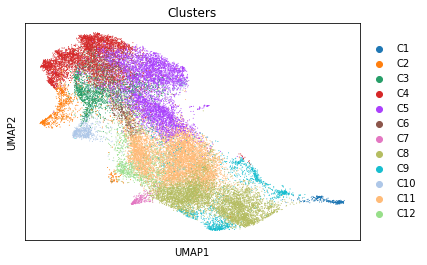

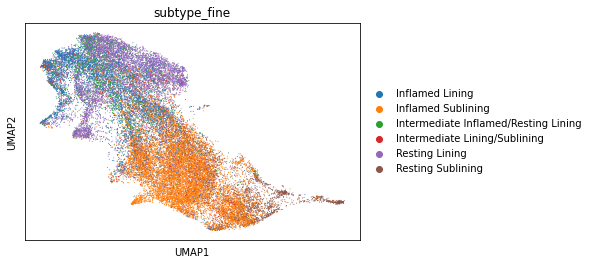

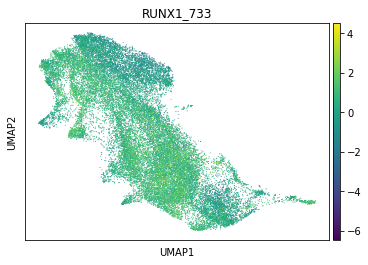

In [7]:
mdata.obsm['X_umap']=mdata.obsm['X_atac_umap']

sc.pl.umap(mdata, color=['Clusters'])
sc.pl.umap(mdata, color=['subtype_fine'])
sc.pl.umap(mdata, color=['RUNX1_733'])



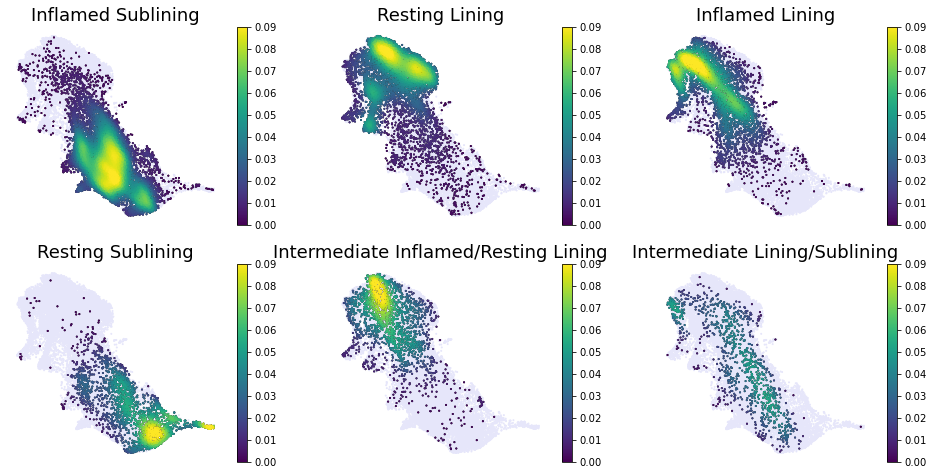

In [8]:
binary_plot(mdata.obsm['X_atac_umap'],mdata.obs['subtype_fine'].values, 
            cat_order=mdata.obs['subtype_fine'].value_counts().index, s = 1, vmax = 0.09, vmin = 0
           )

In [9]:
mdata_var=mdata.var
mdata_var_df = pd.DataFrame(mdata_var) 
mdata_var_df
#mdata_var_df.to_csv('/rds/projects/c/croftap-runx1data01/analysis_of_public_data_sets/SDY2213/meta_mdata.csv')

,motif_id
x,
TFAP2B_1,TFAP2B_1
TFAP2D_2,TFAP2D_2
TFAP2C_3,TFAP2C_3
TFAP2E_4,TFAP2E_4
TFAP2A_5,TFAP2A_5
...,...
SMAD5_866,SMAD5_866
SMAD9_867,SMAD9_867
SOX6_868,SOX6_868


In [12]:
mask = np.column_stack([mdata_var_df[col].str.contains(r"PITX", na=False) for col in mdata_var_df])
mask
mdata_var_df.loc[mask.any(axis=1)]


,motif_id
x,
PITX1_404,PITX1_404
PITX3_426,PITX3_426
PITX2_504,PITX2_504


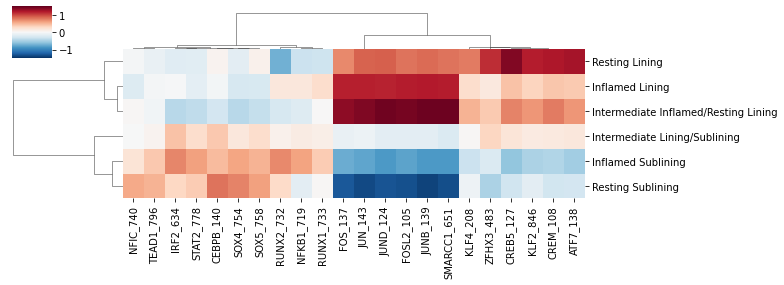

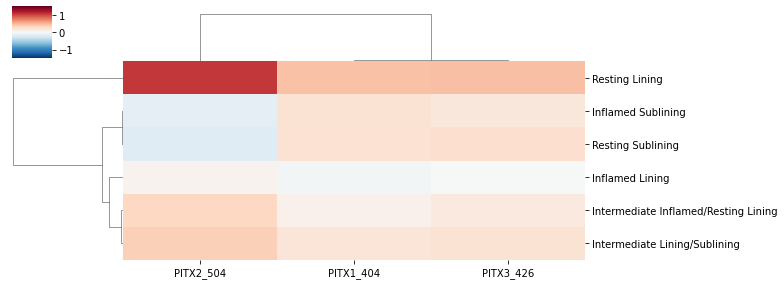

In [15]:



tmp = mdata
clust_mean = pd.DataFrame(np.array(tmp[:,list(['FOSL2_105', 'CREM_108', 'JUND_124', 'CREB5_127', 'FOS_137', 'ATF7_138',
       'JUNB_139', 'CEBPB_140', 'JUN_143', 'KLF4_208', 'ZFHX3_483', 'IRF2_634',
       'SMARCC1_651', 'NFKB1_719', 'RUNX2_732', 'RUNX1_733', 'NFIC_740', 'SOX4_754',
       'SOX5_758', 'STAT2_778', 'TEAD1_796' , 'KLF2_846',
       ])].X),columns=list(['FOSL2_105', 'CREM_108', 'JUND_124', 'CREB5_127', 'FOS_137', 'ATF7_138',
       'JUNB_139', 'CEBPB_140', 'JUN_143', 'KLF4_208', 'ZFHX3_483', 'IRF2_634',
       'SMARCC1_651', 'NFKB1_719', 'RUNX2_732','RUNX1_733', 'NFIC_740', 'SOX4_754',
       'SOX5_758', 'STAT2_778', 'TEAD1_796' , 'KLF2_846',
       ])).groupby(tmp.obs.subtype_fine.values).mean()

g=sns.clustermap(clust_mean, 
               cmap = 'RdBu_r', vmax = 1.5, vmin = -1.5, 
               figsize=(11,4), metric='sqeuclidean', #row_cluster=False
              )




tmp = mdata
clust_mean = pd.DataFrame(np.array(tmp[:,list(['PITX1_404', 'PITX3_426', 'PITX2_504',
       ])].X),columns=list(['PITX1_404', 'PITX3_426', 'PITX2_504',
       ])).groupby(tmp.obs.subtype_fine.values).mean()

g=sns.clustermap(clust_mean, 
               cmap = 'RdBu_r', vmax = 1.5, vmin = -1.5, 
               figsize=(11,4), metric='sqeuclidean', #row_cluster=False
              )



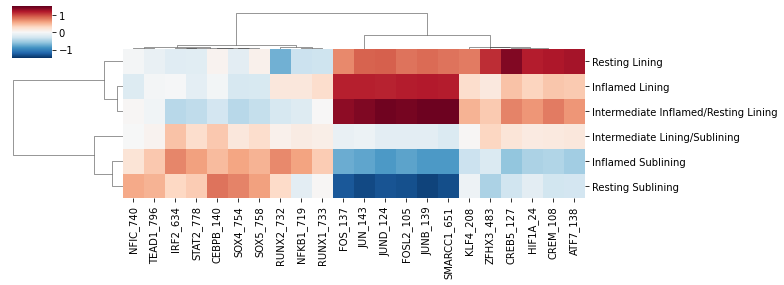

In [29]:
tmp = mdata
clust_mean = pd.DataFrame(np.array(tmp[:,list(['FOSL2_105', 'CREM_108', 'JUND_124', 'CREB5_127', 'FOS_137', 'ATF7_138',
       'JUNB_139', 'CEBPB_140', 'JUN_143', 'KLF4_208', 'ZFHX3_483', 'IRF2_634',
       'SMARCC1_651', 'NFKB1_719', 'RUNX2_732', 'RUNX1_733', 'NFIC_740', 'SOX4_754',
       'SOX5_758', 'STAT2_778', 'TEAD1_796' , 'KLF2_846',
       ])].X),columns=list(['FOSL2_105', 'CREM_108', 'JUND_124', 'CREB5_127', 'FOS_137', 'ATF7_138',
       'JUNB_139', 'CEBPB_140', 'JUN_143', 'KLF4_208', 'ZFHX3_483', 'IRF2_634',
       'SMARCC1_651', 'NFKB1_719', 'RUNX2_732','RUNX1_733', 'NFIC_740', 'SOX4_754',
       'SOX5_758', 'STAT2_778', 'TEAD1_796' , 'HIF1A_24',
       ])).groupby(tmp.obs.subtype_fine.values).mean()

g=sns.clustermap(clust_mean, 
               cmap = 'RdBu_r', vmax = 1.5, vmin = -1.5, 
               figsize=(11,4), metric='sqeuclidean', #row_cluster=False
              )

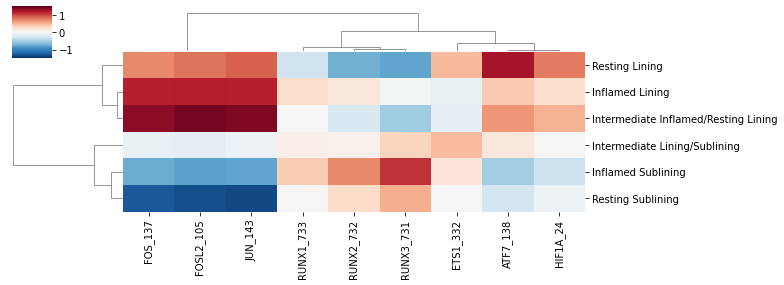

In [22]:


tmp = mdata
clust_mean = pd.DataFrame(np.array(tmp[:,list(['RUNX1_733', 'RUNX2_732', 'RUNX3_731', 'ETS1_332', 'FOSL2_105', 'JUN_143', 'FOS_137', 'ATF7_138', 'KLF4_208',
       ])].X),columns=list(['RUNX1_733', 'RUNX2_732', 'RUNX3_731','ETS1_332', 'FOSL2_105', 'JUN_143', 'FOS_137', 'ATF7_138', 'KLF4_208',
       ])).groupby(tmp.obs.subtype_fine.values).mean()

g=sns.clustermap(clust_mean, 
               cmap = 'RdBu_r', vmax = 1.5, vmin = -1.5, 
               figsize=(11,4), metric='sqeuclidean', #row_cluster=False
              )





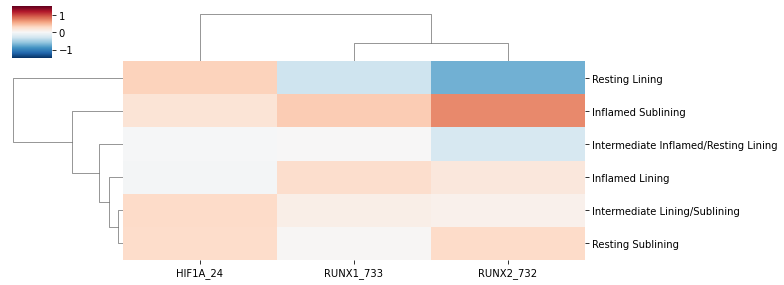

In [30]:
tmp = mdata
clust_mean = pd.DataFrame(np.array(tmp[:,list(['RUNX1_733', 'RUNX2_732', 'RUNX3_731',
       ])].X),columns=list(['RUNX1_733', 'RUNX2_732', 'RUNX3_731',
       ])).groupby(tmp.obs.subtype_fine.values).mean()

g=sns.clustermap(clust_mean, 
               cmap = 'RdBu_r', vmax = 1.5, vmin = -1.5, 
               figsize=(11,4), metric='sqeuclidean', #row_cluster=False
              )

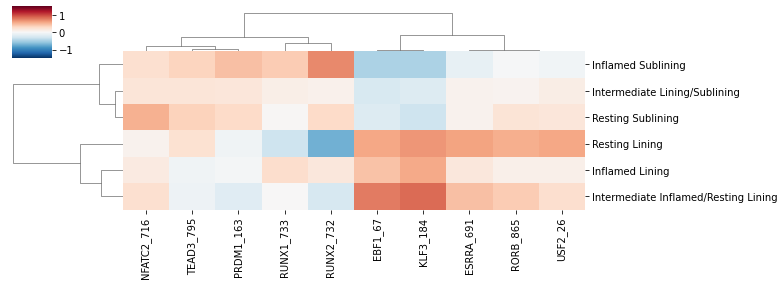

In [4]:
tmp = mdata
clust_mean = pd.DataFrame(np.array(tmp[:,list(['RUNX1_733', 'TEAD3_795', 'NFATC2_716','RUNX2_732', 'PRDM1_163','ESRRA_691','EBF1_67','KLF3_184','RORB_865', 'USF2_26',
       ])].X),columns=list(['RUNX1_733', 'TEAD3_795', 'NFATC2_716','RUNX2_732', 'PRDM1_163','ESRRA_691','EBF1_67','KLF3_184','RORB_865', 'USF2_26',
       ])).groupby(tmp.obs.subtype_fine.values).mean()

g=sns.clustermap(clust_mean, 
               cmap = 'RdBu_r', vmax = 1.5, vmin = -1.5, 
               figsize=(11,4), metric='sqeuclidean', #row_cluster=False
              )

[None, None, None, None, None, None]

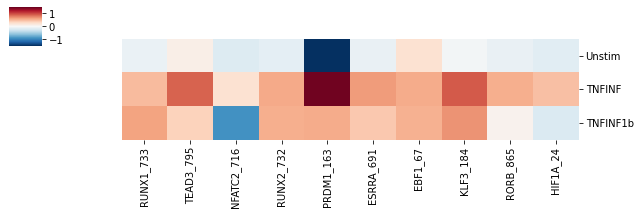

In [18]:
%matplotlib inline
tmp = mdata_combined
clust_mean = pd.DataFrame(np.array(tmp[:,list(['RUNX1_733', 'TEAD3_795', 'NFATC2_716','RUNX2_732', 'PRDM1_163','ESRRA_691','EBF1_67','KLF3_184','RORB_865', 'USF2_26',]
)].X),columns=list(['RUNX1_733', 'TEAD3_795', 'NFATC2_716','RUNX2_732', 'PRDM1_163','ESRRA_691','EBF1_67','KLF3_184','RORB_865', 'USF2_26',]
)).groupby(tmp.obs.condition.values).mean()

g=sns.clustermap(clust_mean.loc[['Unstim','TNFINF','TNFINF1b']], 
               cmap = 'RdBu_r', vmax = 1.5, vmin = -1.5, 
               figsize=(9,3), metric='sqeuclidean', row_cluster=False, 
                 col_cluster = False
              )
plt.setp(g.ax_heatmap.yaxis.get_majorticklabels(), rotation=0)


%matplotlib inline
tmp = mdata_combined
clust_mean = pd.DataFrame(np.array(tmp[:,list(['RUNX1_733', 'TEAD3_795', 'NFATC2_716','RUNX2_732', 'PRDM1_163','ESRRA_691','EBF1_67','KLF3_184','RORB_865', 'HIF1A_24',]
)].X),columns=list(['RUNX1_733', 'TEAD3_795', 'NFATC2_716','RUNX2_732', 'PRDM1_163','ESRRA_691','EBF1_67','KLF3_184','RORB_865', 'HIF1A_24',]
)).groupby(tmp.obs.condition.values).mean()

g=sns.clustermap(clust_mean.loc[['Unstim','TNFINF','TNFINF1b']], 
               cmap = 'RdBu_r', vmax = 1.5, vmin = -1.5, 
               figsize=(9,3), metric='sqeuclidean', row_cluster=False, 
                 col_cluster = False
              )
plt.setp(g.ax_heatmap.yaxis.get_majorticklabels(), rotation=0)






[None, None, None, None, None, None]

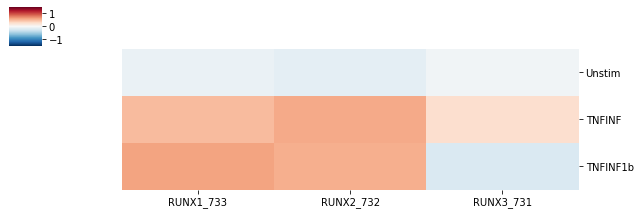

In [6]:
%matplotlib inline
tmp = mdata_combined
clust_mean = pd.DataFrame(np.array(tmp[:,list(['RUNX1_733', 'RUNX2_732', 'RUNX3_731',]
)].X),columns=list(['RUNX1_733', 'RUNX2_732', 'RUNX3_731',]
)).groupby(tmp.obs.condition.values).mean()

g=sns.clustermap(clust_mean.loc[['Unstim','TNFINF','TNFINF1b']], 
               cmap = 'RdBu_r', vmax = 1.5, vmin = -1.5, 
               figsize=(9,3), metric='sqeuclidean', row_cluster=False, 
                 col_cluster = False
              )
plt.setp(g.ax_heatmap.yaxis.get_majorticklabels(), rotation=0)

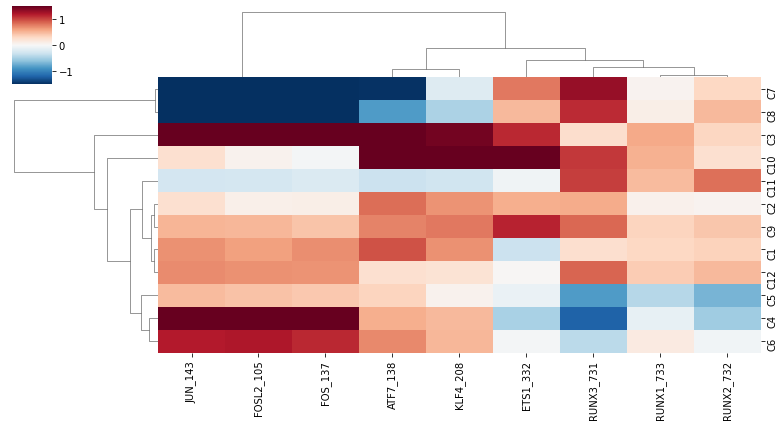

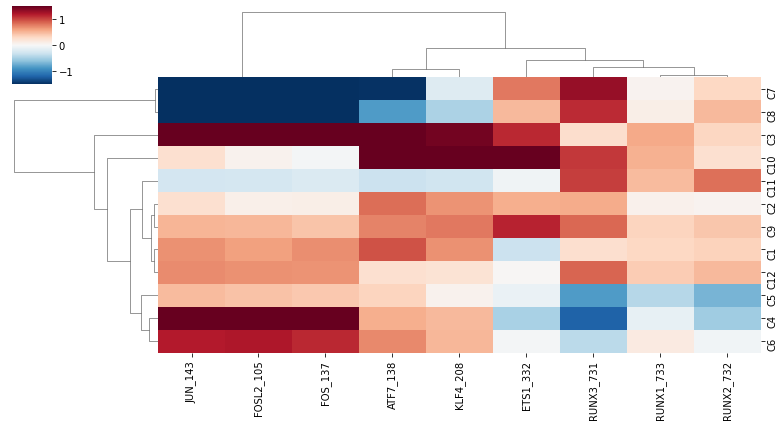

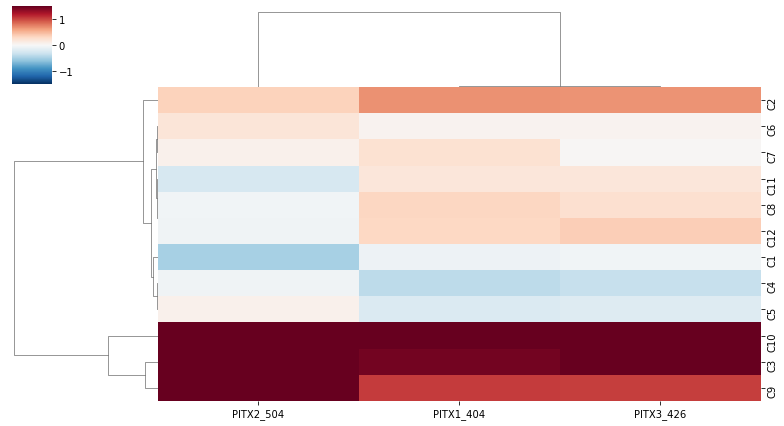

In [19]:
tmp = mdata
clust_mean = pd.DataFrame(np.array(tmp[:,list(['RUNX1_733', 'RUNX2_732', 'RUNX3_731', 'ETS1_332', 'FOSL2_105', 'JUN_143', 'FOS_137', 'ATF7_138', 'KLF4_208',
       ])].X),columns=list(['RUNX1_733', 'RUNX2_732', 'RUNX3_731', 'ETS1_332', 'FOSL2_105', 'JUN_143', 'FOS_137', 'ATF7_138', 'KLF4_208',
       ])).groupby(tmp.obs.Clusters.values).mean()

g=sns.clustermap(clust_mean, 
               cmap = 'RdBu_r', vmax = 1.5, vmin = -1.5, 
               figsize=(11,6), metric='sqeuclidean', #row_cluster=False
              )



tmp = mdata
clust_mean = pd.DataFrame(np.array(tmp[:,list(['RUNX1_733', 'RUNX2_732', 'RUNX3_731', 'ETS1_332', 'FOSL2_105', 'JUN_143', 'FOS_137', 'ATF7_138', 'KLF4_208',
       ])].X),columns=list(['RUNX1_733', 'RUNX2_732', 'RUNX3_731', 'ETS1_332', 'FOSL2_105', 'JUN_143', 'FOS_137', 'ATF7_138', 'KLF4_208',
       ])).groupby(tmp.obs.Clusters.values).mean()

g=sns.clustermap(clust_mean, 
               cmap = 'RdBu_r', vmax = 1.5, vmin = -1.5, 
               figsize=(11,6), metric='sqeuclidean', #row_cluster=False
              )


tmp = mdata
clust_mean = pd.DataFrame(np.array(tmp[:,list(['PITX1_404', 'PITX3_426', 'PITX2_504',
       ])].X),columns=list(['PITX1_404', 'PITX3_426', 'PITX2_504',
       ])).groupby(tmp.obs.Clusters.values).mean()

g=sns.clustermap(clust_mean, 
               cmap = 'RdBu_r', vmax = 1.5, vmin = -1.5, 
               figsize=(11,6), metric='sqeuclidean', #row_cluster=False
              )







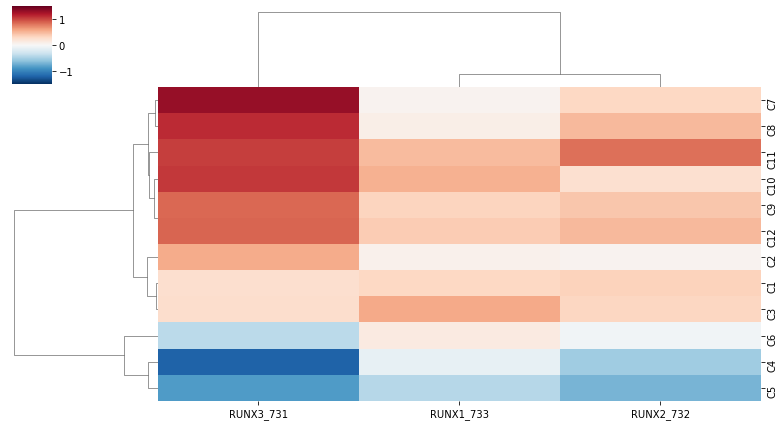

In [9]:
tmp = mdata
clust_mean = pd.DataFrame(np.array(tmp[:,list(['RUNX1_733', 'RUNX2_732', 'RUNX3_731',
       ])].X),columns=list(['RUNX1_733', 'RUNX2_732', 'RUNX3_731',
       ])).groupby(tmp.obs.Clusters.values).mean()

g=sns.clustermap(clust_mean, 
               cmap = 'RdBu_r', vmax = 1.5, vmin = -1.5, 
               figsize=(11,6), metric='sqeuclidean', #row_cluster=False
              )

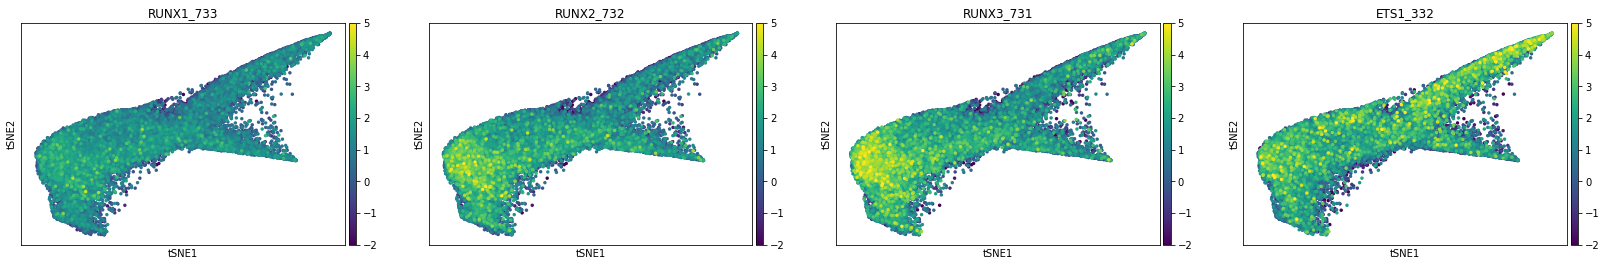

In [55]:
mdata.obsm['X_tsne'] = adata[mdata.obs.index].obsm['X_fd']
sc.pl.tsne(mdata, color = ['RUNX1_733', 'RUNX2_732', 'RUNX3_731', 'ETS1_332',],
           vmax = 5,
           vmin = -2, 
           cmap = 'viridis', s = 48,
      )

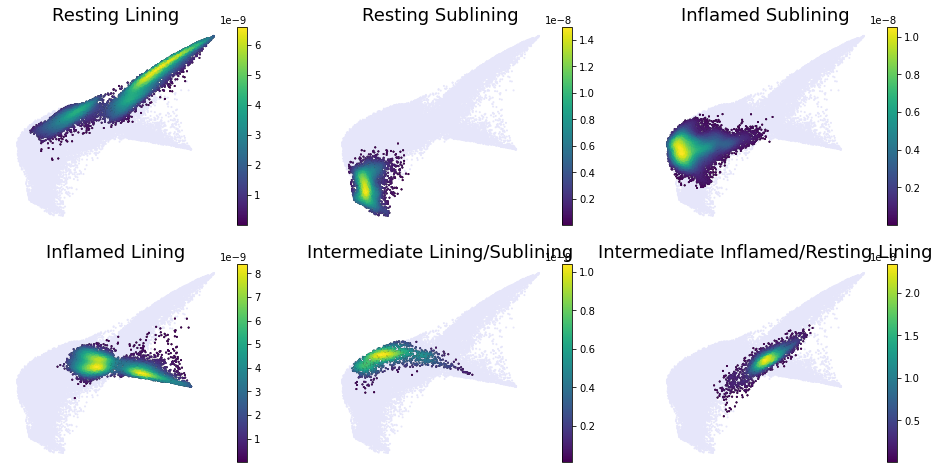

In [56]:
binary_plot(adata.obsm['X_fd'],adata.obs['subtype_fine'], cat_order=['Resting Lining',
 'Resting Sublining',
 'Inflamed Sublining',
 'Inflamed Lining',
 'Intermediate Lining/Sublining','Intermediate Inflamed/Resting Lining'
], s = 1
           )

In [69]:
clust_mean = pd.DataFrame(np.array(adata[:,['CLIC5','HBEGF','PRG4','CD55','CRTAC1','HLA-DRA',
                'CD74','FN1','CXCL1','MMP3','CXCL12','CCL2','APOE','IL6',
                'SFRP1','KAZN','COL3A1','NOTCH3','CDH11','DKK3','POSTN',
                'ASPN','SPARC','CD34','MFAP5','PI16','VCAN','THY1',
                'LRP1B','SLIT2','DCN','CFD','RSPO3']].X),columns=['CLIC5','HBEGF','PRG4','CD55','CRTAC1','HLA-DRA',
                'CD74','FN1','CXCL1','MMP3','CXCL12','CCL2','APOE','IL6',
                'SFRP1','KAZN','COL3A1','NOTCH3','CDH11','DKK3','POSTN',
                'ASPN','SPARC','CD34','MFAP5','PI16','VCAN','THY1',
                'LRP1B','SLIT2','DCN','CFD','RSPO3']).groupby(adata.obs.subtype_fine.values).mean()




ValueError: Must pass 2-d input. shape=()

In [ ]:
sc.set_figure_params(scanpy=True, fontsize=12)

sns.clustermap(clust_mean, 
               cmap = 'RdBu_r', vmax = 1.2, vmin = -1.2, figsize=(12,3), 
               metric='sqeuclidean', 
#                row_cluster=False
              )

In [81]:
mdata_combined

AnnData object with n_obs × n_vars = 56478 × 870
    obs: 'BlacklistRatio', 'nDiFrags', 'nFrags', 'nMonoFrags', 'nMultiFrags', 'NucleosomeRatio', 'PassQC', 'PromoterRatio', 'ReadsInBlacklist', 'ReadsInPromoter', 'ReadsInTSS', 'Sample', 'TSSEnrichment', 'ReadsInPeaks', 'FRIP', 'condition'
    var: 'x'

In [84]:
import dill
dill.dump_session('/rds/projects/c/croftap-runx1data01/analysis_of_public_data_sets/SDY2213/RNA_ATACanalysis.db')